In [8]:
import sys
!{sys.executable} -m pip install scikit-learn

# Uncomment and run the following lines to check if imports succeeded
# import sys
# !{sys.executable} -m pip show scikit-learn

# Model

In [14]:
import matplotlib.pyplot as plt

class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2, scheduler=True):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=l2)
        self.scheduler = None
        if scheduler:
            self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau
                (self.optimizer, factor=0.5, patience=10, threshold=1e-4)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(batch_size=self.batch_size).cache()
        
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        lr_list = []
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(true_energies, pred_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()

                train_epoch_loss += batch_loss.detach().cpu().item()
            
            # use the self.evaluate to get loss on the validation set 
            # Evaluation and plotting (predicted vs. ground truth) performed after every epoch
            val_epoch_loss = self.evaluate(val_data, draw_plot=(True if i % 5 == 0 else False))
            
            if self.scheduler:
                current_lr = self.optimizer.param_groups[0]['lr']
                lr_list.append(current_lr)
                self.scheduler.step(val_epoch_loss)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss) # Total, batch-importance-weighted validation loss for this epoch
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()

        # Plots train and val loss vs. epoch # (one graph total). Val loss performed on same validation set
        if draw_curve:
            hartree2kcalmol = 627.5094738898777
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(np.arange(self.epoch), np.array(train_loss_list) * hartree2kcalmol, label='Train')
            ax.plot(np.arange(self.epoch), np.array(val_loss_list) * hartree2kcalmol, label='Validation')
            ax.legend()
            ax.set_xlabel("Epoch #")
            ax.set_ylabel("Loss (RMSE, kcal/mol)")

            if self.scheduler:
                lr_fig, lr_ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
                # lr_ax.set_yscale("log")
                # Plot learning rate against epoch #
                lr_ax.plot(np.arange(self.epoch), lr_list, label='Learning Rate')
                lr_ax.legend()
                lr_ax.set_xlabel("Epoch #")
                lr_ax.set_ylabel("Learning Rate")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(batch_size=self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                total_loss += batch_loss.detach().cpu().item()

                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all)) * hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss
        

In [10]:
# All code in this cell is from Checkpoint 1:

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
#########################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

#########################

def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

#########################

def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

#########################

class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

#########################

cuda
384


In [11]:
# Cross Validation
from sklearn.model_selection import KFold
from torchani.data import TransformableIterable

def KFoldCrossValidation(
    model, training_data, test_data,
    k=3, learning_rate=2e-3, batch_size=1024, epoch=100, l2=1e-5,
    early_break=False
):
    training_data = list(training_data)
    kf = KFold(n_splits=k, shuffle=True)
    best_train_loss_list, test_loss_list = [], []
    # 1 hartree = 627.5094738898777 kcal/mol
    hartree2kcalmol = 627.5094738898777
    
    for i, (train_index, val_index) in enumerate(kf.split(training_data)):
        print(f"Fold {i}:")
        
        train_data = TransformableIterable([training_data[j] for j in train_index])
        val_data = TransformableIterable([training_data[j] for j in val_index])

        trainer = ANITrainer(model, batch_size, learning_rate, epoch, l2, scheduler=True)
        train_loss_list, val_loss_list = trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
        train_loss_best = np.min(train_loss_list)
        test_loss = trainer.evaluate(test_data)
        
        best_train_loss_list.append(train_loss_best)
        test_loss_list.append(test_loss)
        
        print(f"Training MSE Loss: {train_loss_best}")
        print(f"Test MSE Loss: {test_loss}")
        print(f"Training RMSE Loss (kcal/mol): {train_loss_best * (hartree2kcalmol)}")
        print(f"Test RMSE Loss (kcal/mol): {test_loss  * (hartree2kcalmol)}")
        
        if early_break:
            break
    
    if not early_break:
        print("\n")
        print("----------------------- Final Results -----------------------")
        print("\n")
        print(f"Training MSE Loss: {np.mean(best_train_loss_list)}+/-{np.std(best_train_loss_list)}")
        print(f"Test MSE Loss: {np.mean(test_loss_list)}+/-{np.std(test_loss_list)}")
        print(f"Training RMSE Loss (kcal/mol)): 
            {np.mean(best_train_loss_list) * (hartree2kcalmol)}+/-{np.std(best_train_loss_list) * (hartree2kcalmol)}")
        print(f"Test RMSE Loss (kcal/mol)): 
            {np.mean(test_loss_list) * (hartree2kcalmol)}+/-{np.std(test_loss_list) * (hartree2kcalmol)}")

# Data Processing

In [15]:
# ANI model requires a network for each atom type
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
train_data, test_data = dataset.split(0.0008, 0.0002)
print(len(train_data))

691


# Training and Visualization

Fold 0:
Sequential - Number of parameters: 230404
Initialize training data...


100%|██████████| 100/100 [00:31<00:00,  3.20it/s]
/tmp/ipykernel_2061268/4094664201.py:76: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)


Training MSE Loss: 0.0005630894447676837
Test MSE Loss: 0.001736122532747686
Training RMSE Loss (kcal/mol): 0.35334396123911255
Test RMSE Loss (kcal/mol): 1.0894333371328622
Fold 1:
Sequential - Number of parameters: 230404
Initialize training data...


100%|██████████| 100/100 [00:32<00:00,  3.04it/s]


Training MSE Loss: 0.0004246763710398227
Test MSE Loss: 0.0019413901027292013
Training RMSE Loss (kcal/mol): 0.2664884461646616
Test RMSE Loss (kcal/mol): 1.2182406819786167
Fold 2:
Sequential - Number of parameters: 230404
Initialize training data...


100%|██████████| 100/100 [00:34<00:00,  2.91it/s]


Training MSE Loss: 0.00031837710412219167
Test MSE Loss: 0.0012080789310857654
Training RMSE Loss (kcal/mol): 0.19978464910629928
Test RMSE Loss (kcal/mol): 0.7580809744630744


----------------------- Final Results -----------------------


Training MSE Loss: 0.0004353809733098994+/-0.00010018973266880273
Test MSE Loss: 0.0016285305221875508+/-0.00030888870613490803
Training RMSE Loss (kcal/mol)): 0.27320568550335783+/-0.06287000643616789
Test RMSE Loss (kcal/mol)): 1.0219183311915176+/-0.19383058947724116


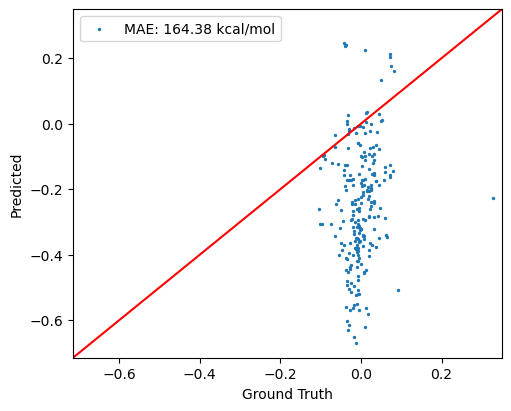

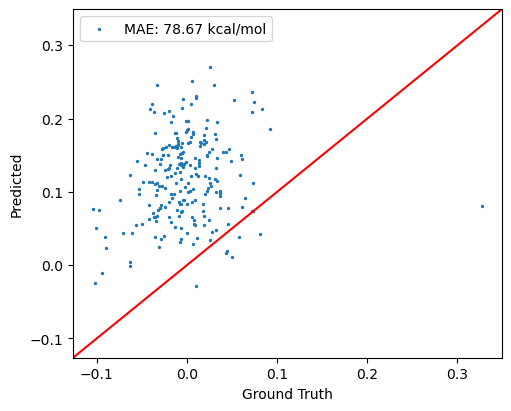

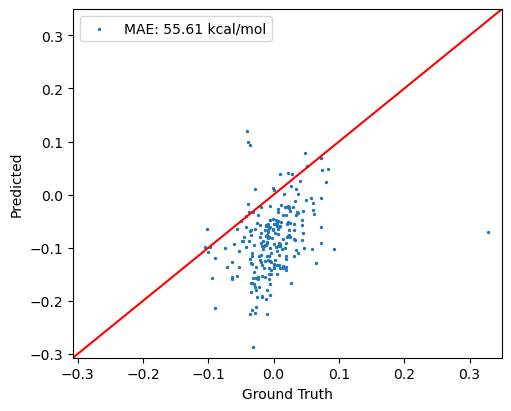

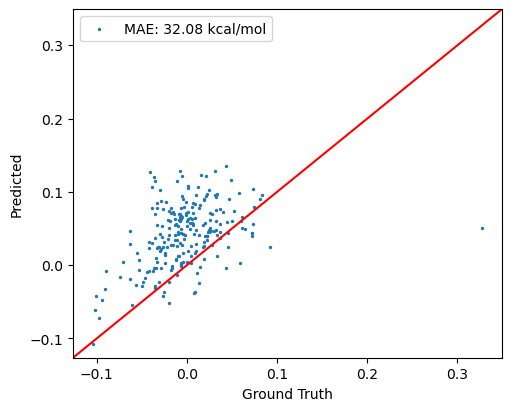

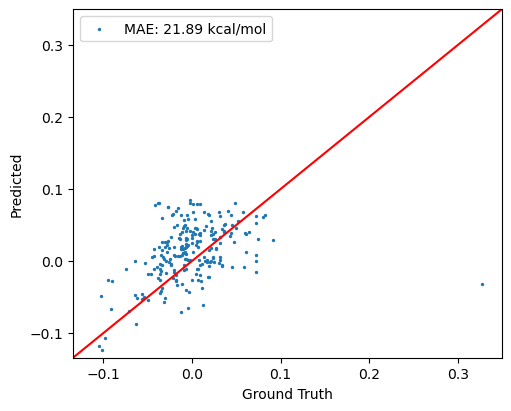

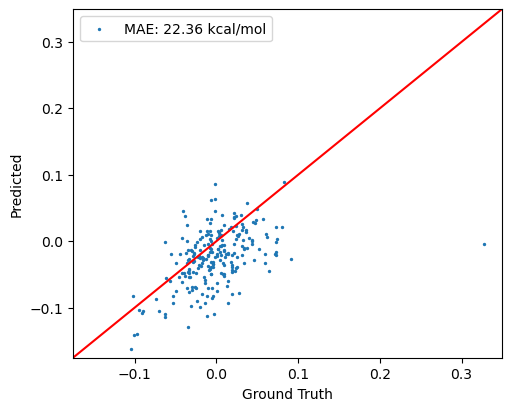

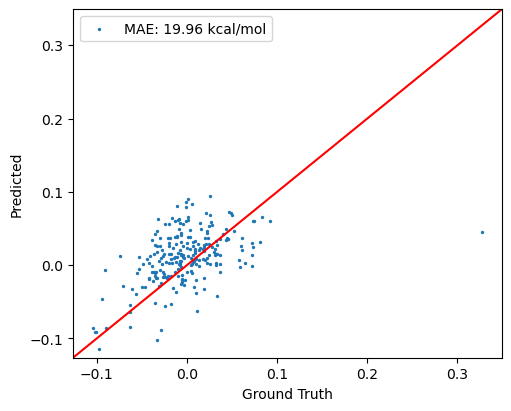

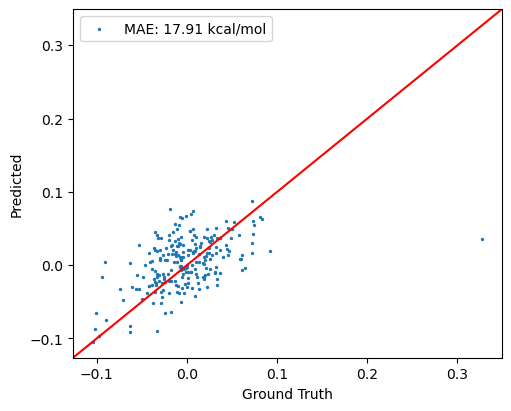

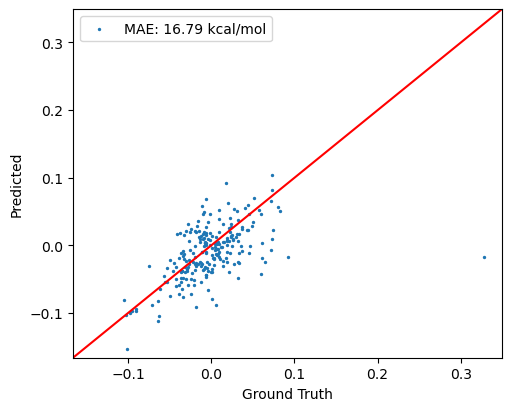

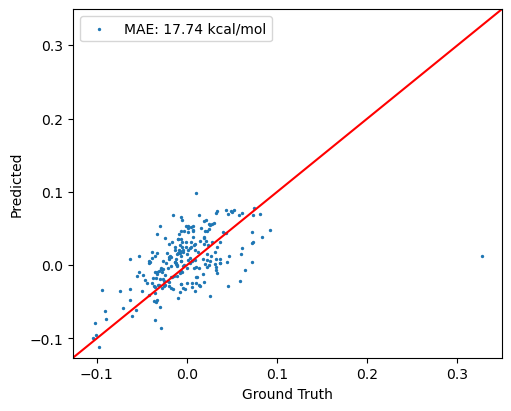

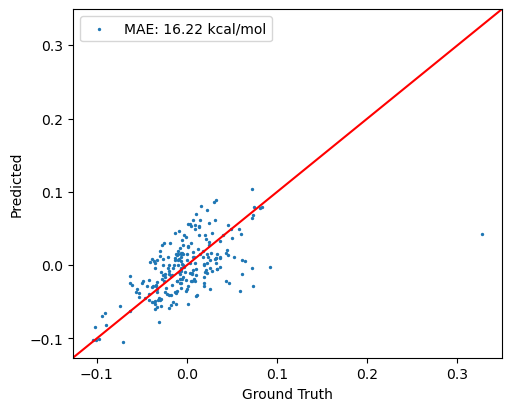

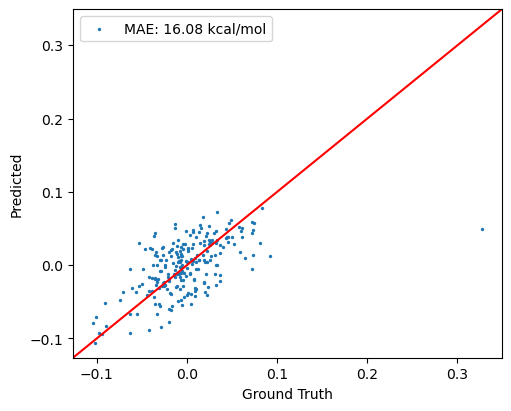

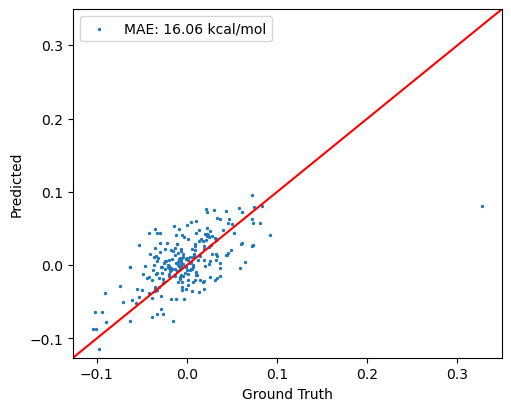

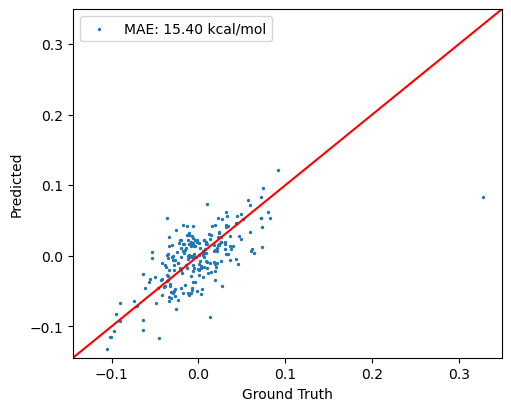

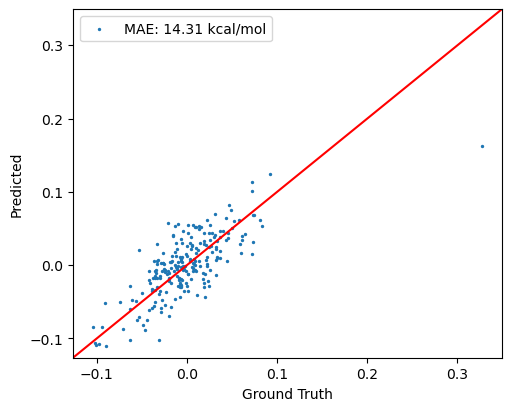

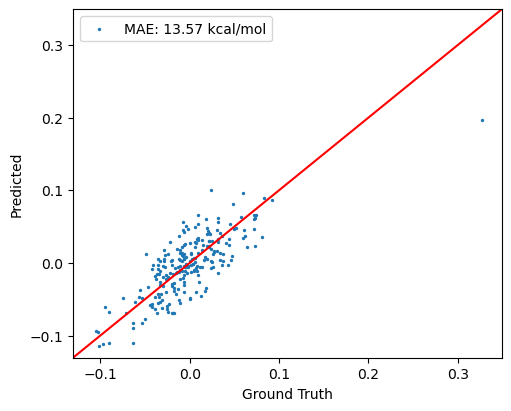

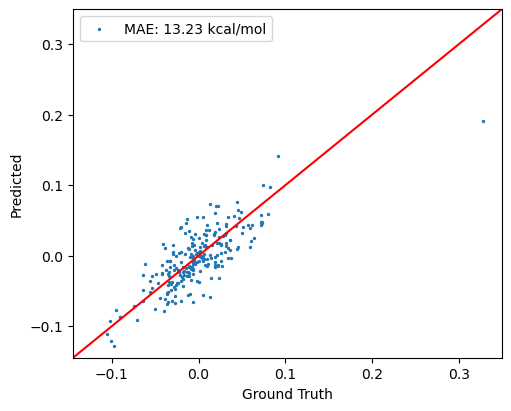

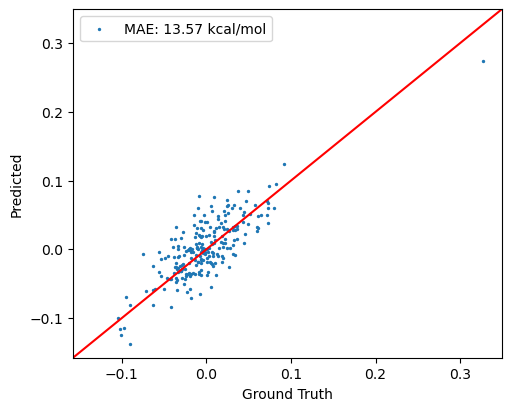

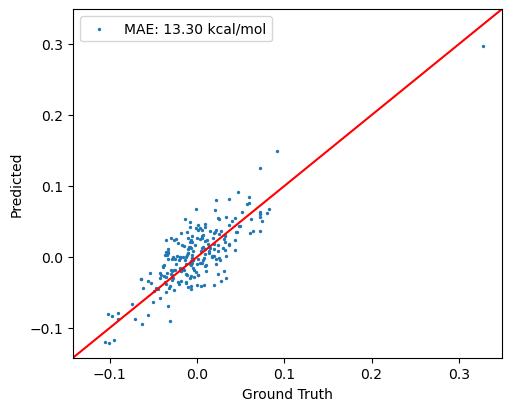

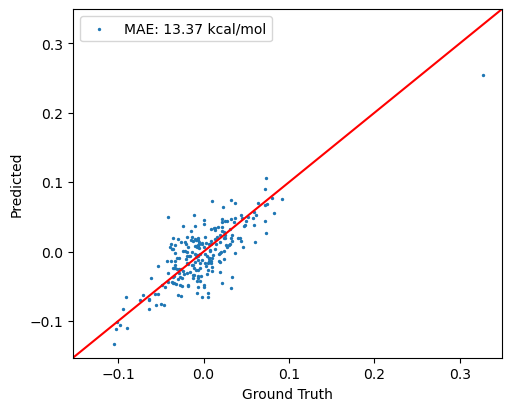

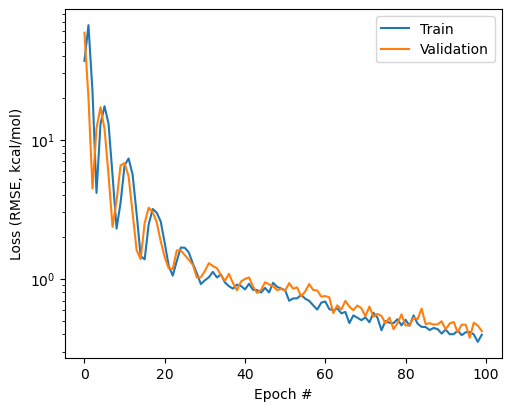

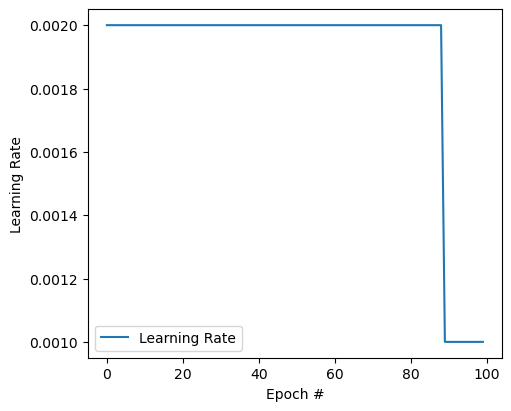

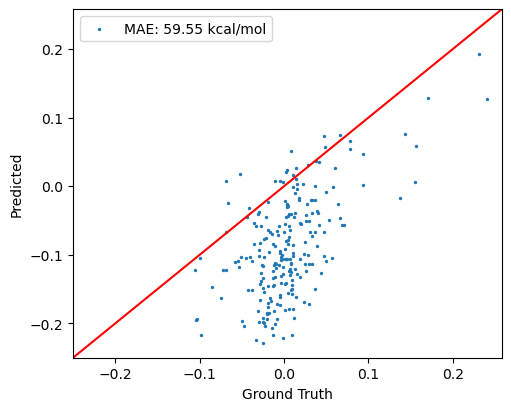

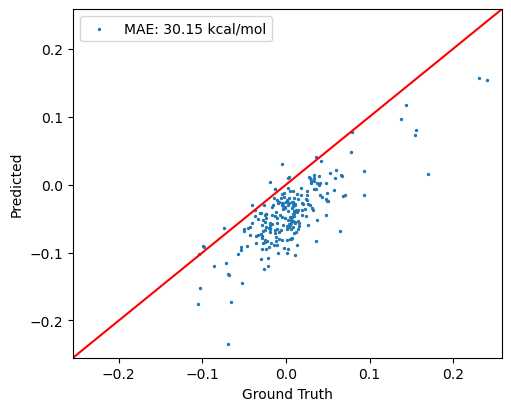

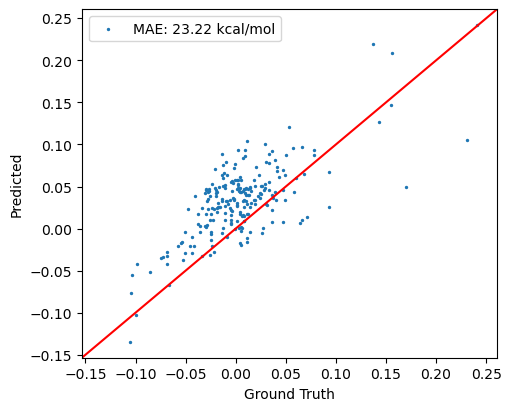

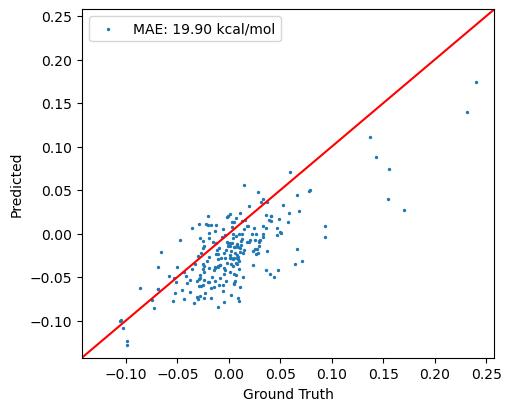

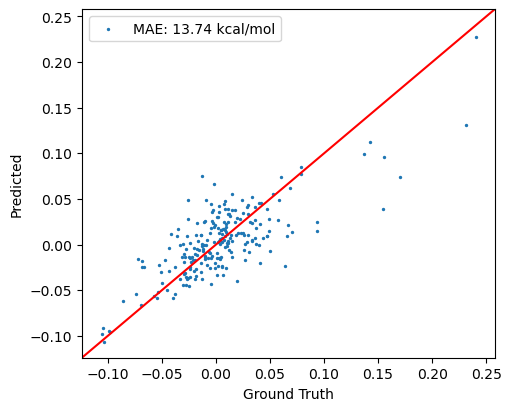

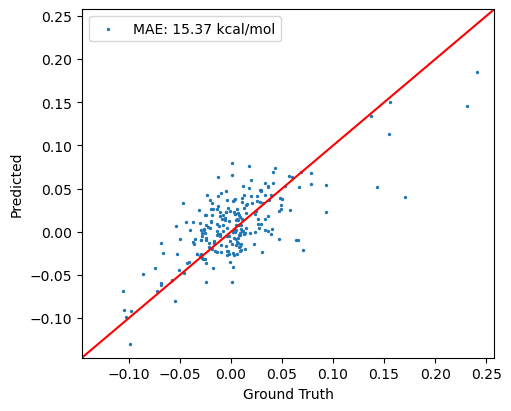

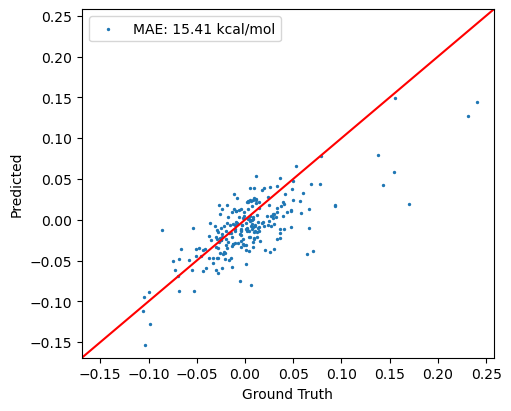

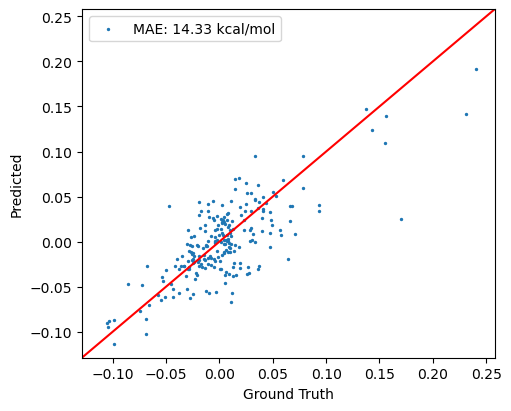

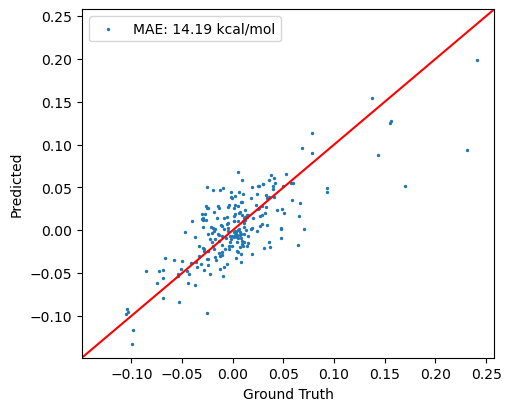

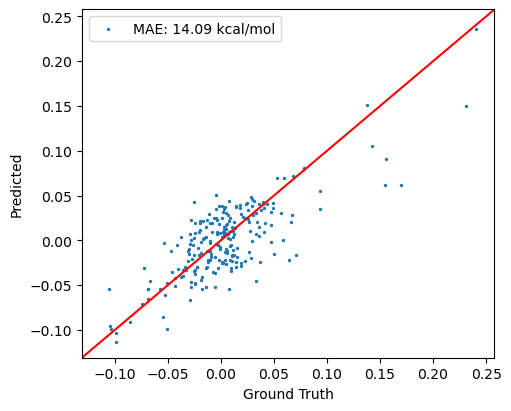

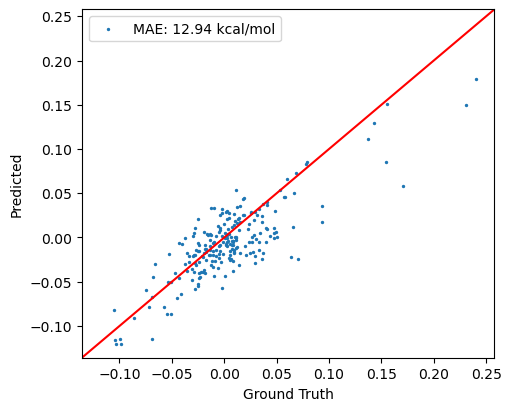

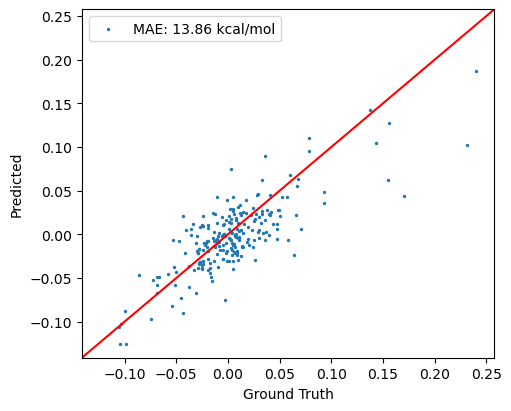

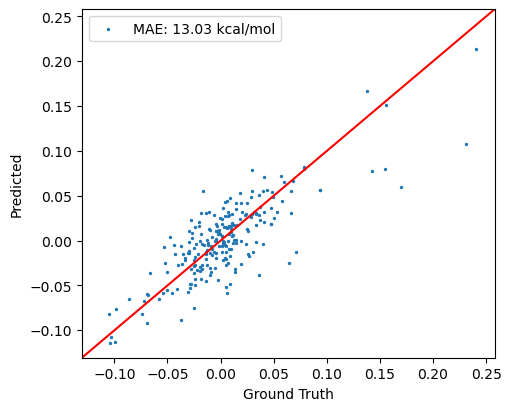

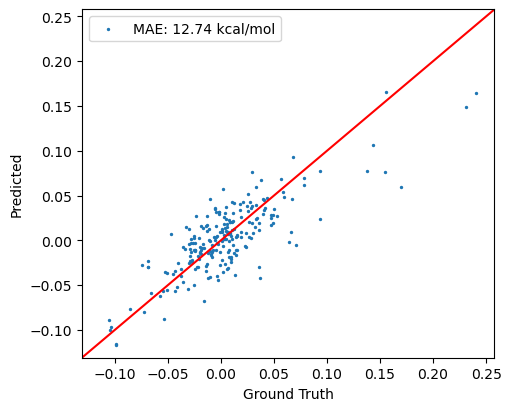

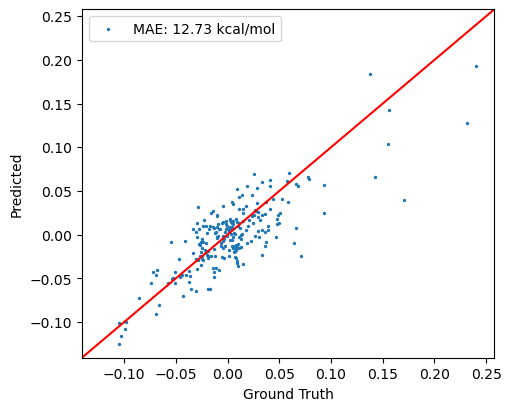

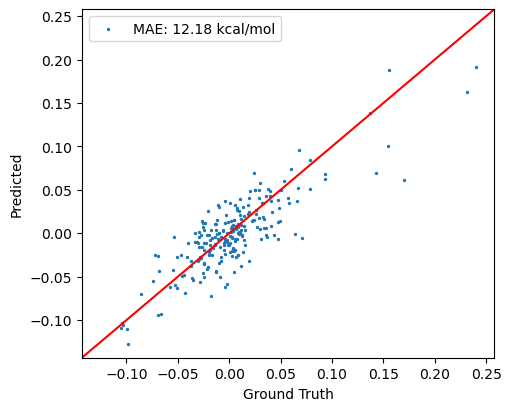

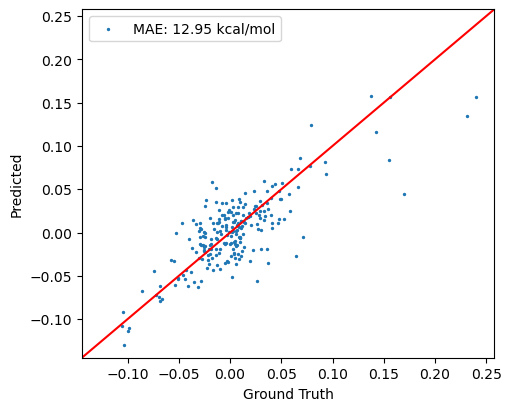

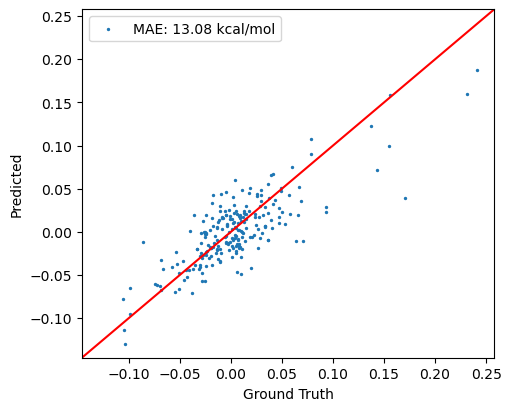

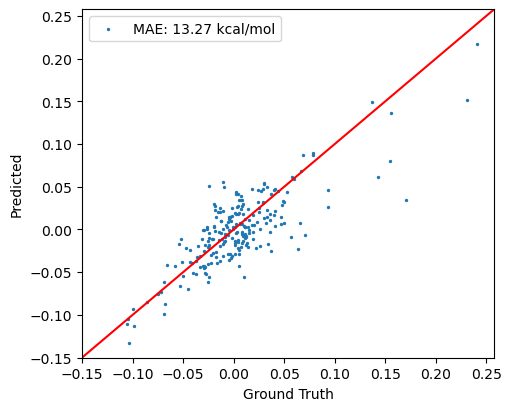

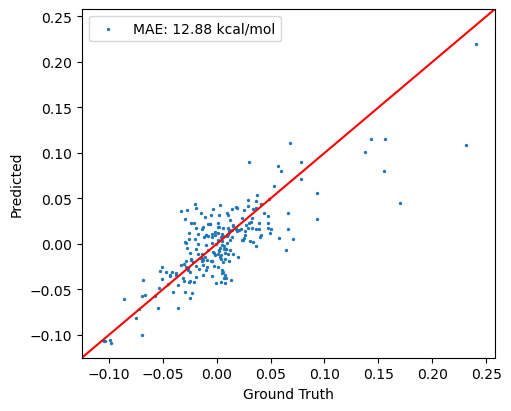

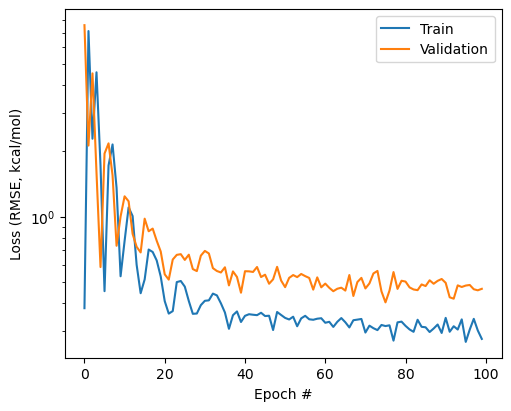

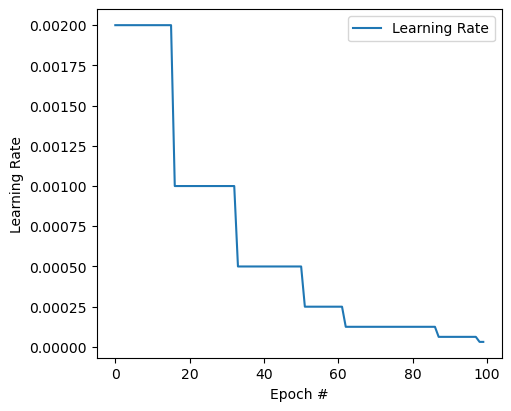

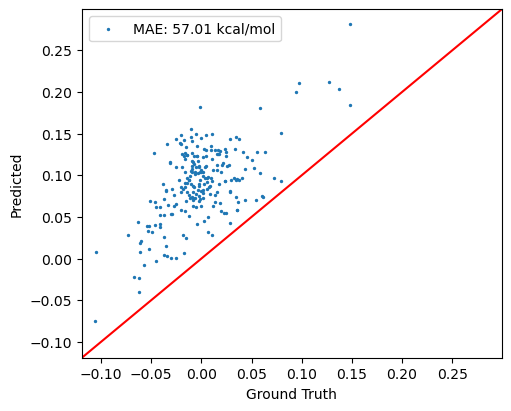

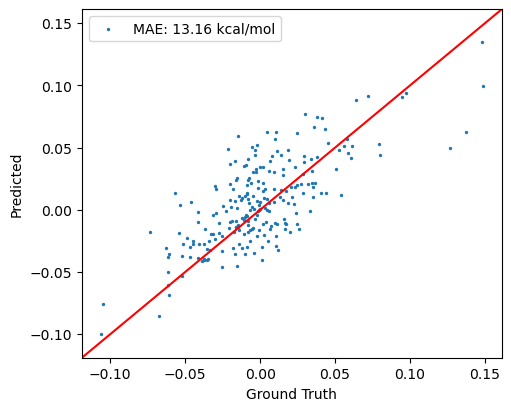

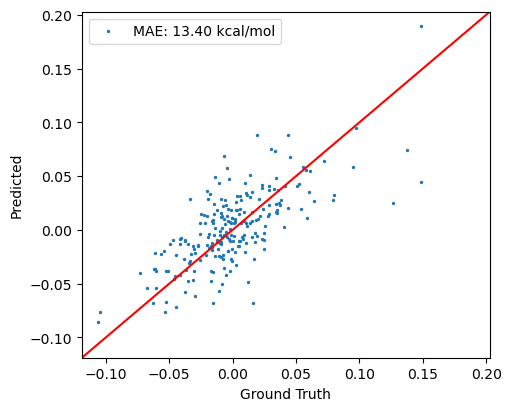

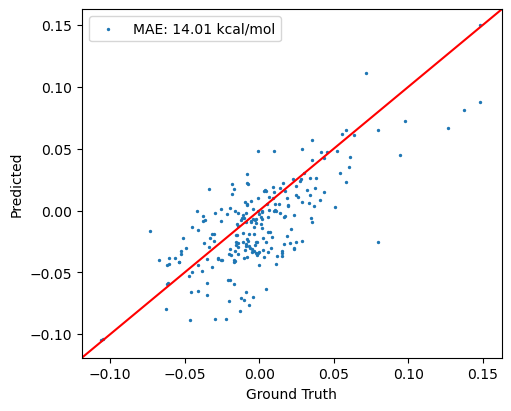

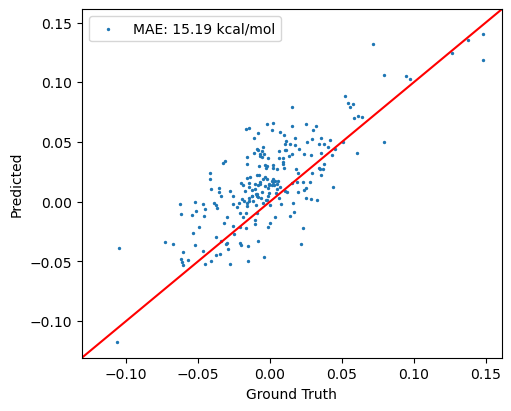

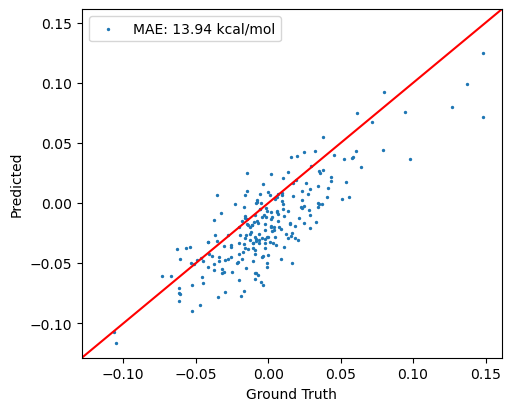

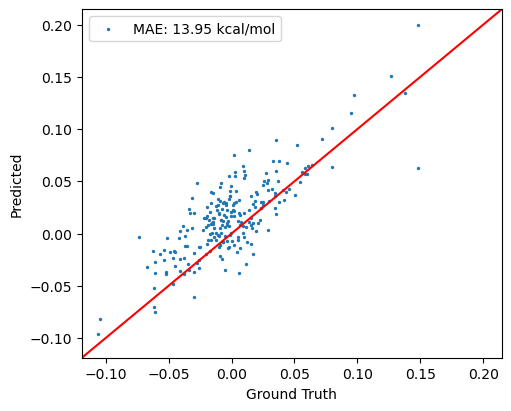

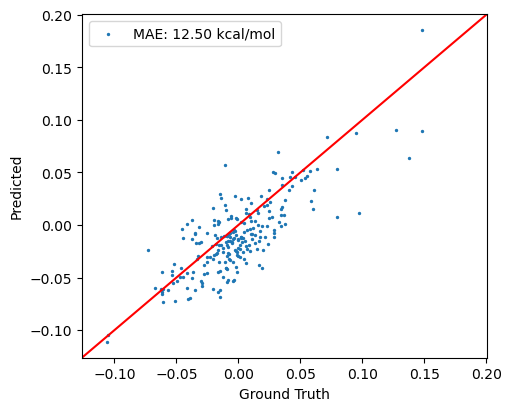

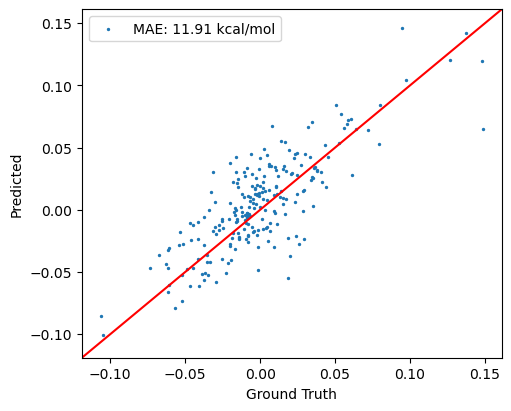

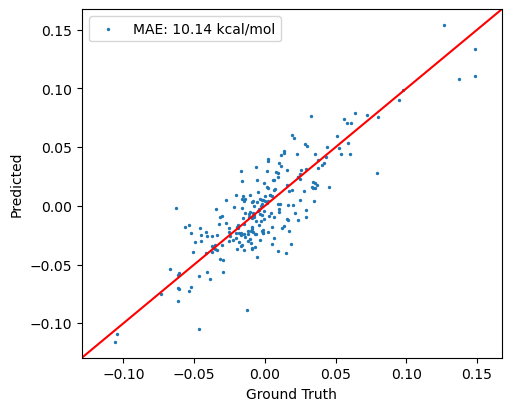

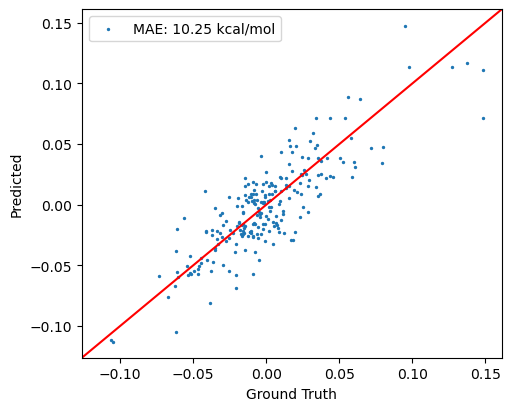

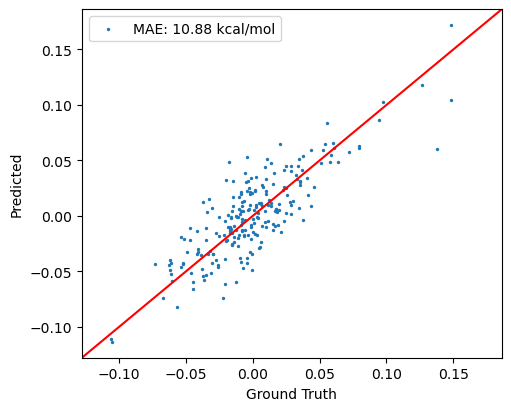

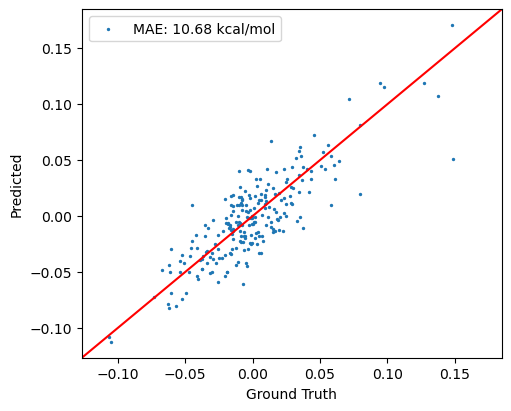

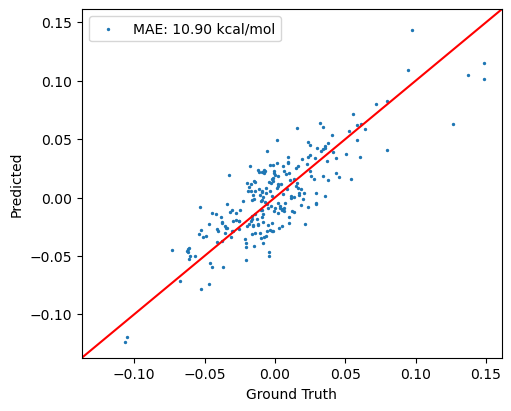

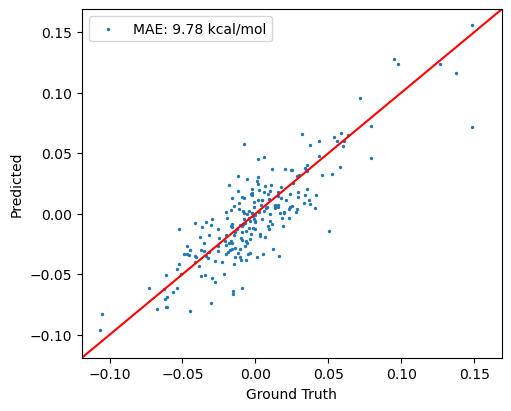

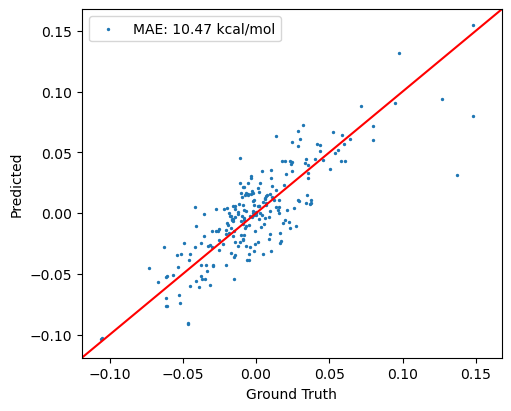

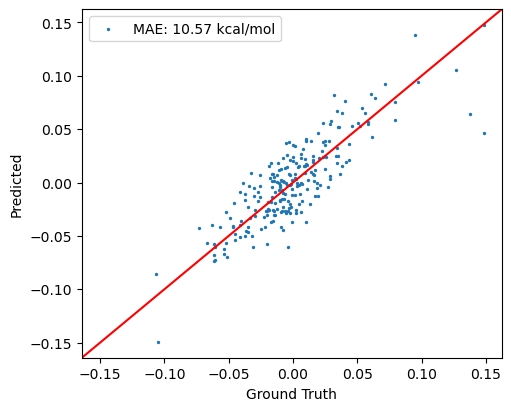

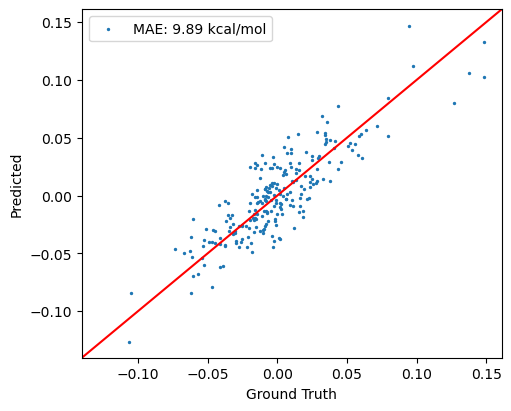

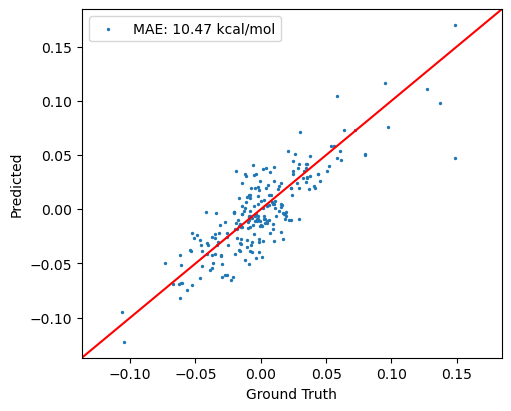

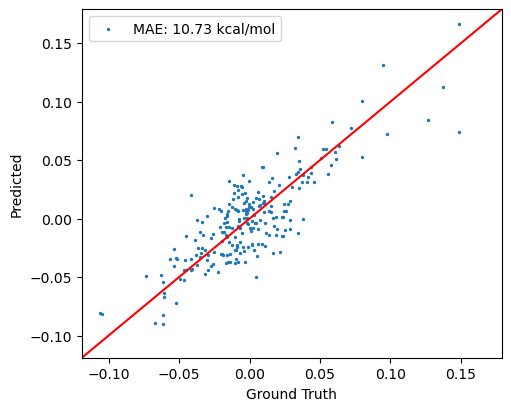

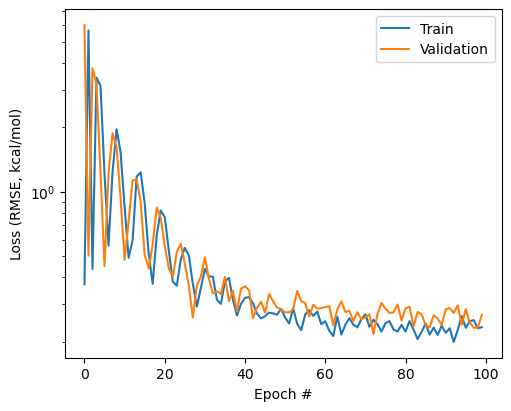

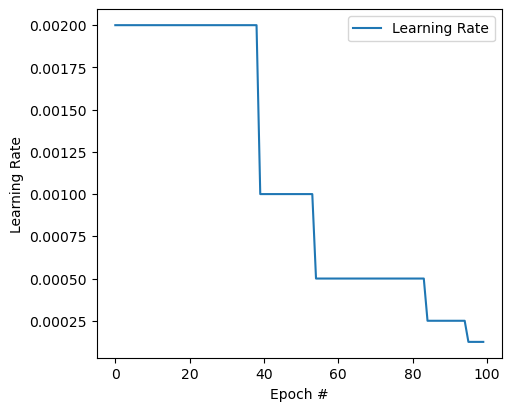

In [16]:
KFoldCrossValidation(
    model, train_data, test_data,
    k=3, learning_rate=2e-3, batch_size=1024, epoch=100, l2=1e-5,
    early_break=False
)